In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data=pd.read_csv("Covid-19 Hesitancy Form.csv")
data.head(2)

,Timestamp,Gender,Age,Location,Educational background,Are you vaccinated?,Which dose have you taken?,What kind of vaccine did you take? (1st dose),What kind of vaccine did you take? (2nd dose),What were the side effects you experienced after taking the vaccination? (1st dose),...,If you are given a choice. How likely is it that you are gonna take the vaccination shot if your vaccine is Pfizer-BioNTech ?,What is the reason for your answer above for Pfizer-BioNTech ?,If you are given a choice. How likely is it that you are gonna take the vaccination shot if your vaccine is AstraZeneca ?,What is the reason for your answer above for AstraZeneca ?,If you are given a choice. How likely is it that you are gonna take the vaccination shot if your vaccine is Sinovac?,What is the reason for your answer above for Sinovac ?,If you are given a choice. How likely is it that you are gonna take the vaccination shot if your vaccine is CanSino ?,What is the reason for your answer above for CanSino ?,Do you have other preferred vaccine brand that is NOT listed in this survey?,"If your answer is YES, what is the name of the vaccine brand that is NOT in this survey"
0,2022/11/03 1:21:34 PM GMT+8,Male,18,Countryside,None of the above,"Yes, I took the vaccine",Dose 2,Pfizer-BioNTech,Pfizer-BioNTech,"Most common side effects (i.e. headache, injec...",...,4,Influence from friends/family/colleague,2,Influence from friends/family/colleague,1,Influence from friends/family/colleague,1,Influence from friends/family/colleague,No,NaN
1,2022/11/03 1:21:54 PM GMT+8,Female,24,Urban,None of the above,"Yes, I took the vaccine",Dose 1;Dose 2;Booster 1,AstraZeneca,Pfizer-BioNTech,"Common side effects (i.e. fever, vomitting)",...,5,Success rate of the vaccine;Influence from fri...,5,Success rate of the vaccine;Influence from fri...,2,Success rate of the vaccine;Influence from soc...,4,Success rate of the vaccine;Influence from soc...,No,NaN


In [ ]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)


In [ ]:
data.shape

(106, 34)

In [ ]:
data.columns

Index(['Timestamp', 'Gender', 'Age', 'Location', 'Educational background',
       'Are you vaccinated?', 'Which dose have you taken?',
       'What kind of vaccine did you take? (1st dose)',
       'What kind of vaccine did you take? (2nd dose)',
       'What were the side effects you experienced after taking the vaccination? (1st dose)',
       'What were the side effects you experienced after taking the vaccination? (2nd dose)',
       'If you took booster 1 shot, what kind of vaccine did you take? (Booster 1)',
       'If you took booster 2 shot, what kind of vaccine did you take? (Booster 2)',
       'What motivates you to get vaccination?',
       'Did your whole family (parents and siblings) got vaccinated?',
       'Have you lost someone due to Covid-19?',
       'If the 5th Covid-19 vaccine shot is available, are you willing to get vaccinated?',
       'Are you willing to get vaccinated?',
       'What makes you hesitate or unwilling to get vaccinated?',
       'Did your whole 

In [ ]:
#Change columns name
data.columns=['time','gender','age','loc','edu_background','vaccinated','dose','vacc1_type','vacc2_type','side_effect1','side_effect2',
           'vacc_type_booster1','vacc_type_booster2','motivation','family_vaccinated','lost_vaccinated','5th_vacc',
           'willing','hesitation','family_unvaccinated','lost_unvaccinated','knowledge','awareness','5th_vacc_unvaccinated',
           'pfizer_rate','reason_pfizer','astrazeneca_rate','reason_astrazeneca','sinovac_rate','reason_sinovac','cansino_rate','reason_cansino',
           'other_vacc','other_vacc_name']

data.head(2)

,time,gender,age,loc,edu_background,vaccinated,dose,vacc1_type,vacc2_type,side_effect1,...,pfizer_rate,reason_pfizer,astrazeneca_rate,reason_astrazeneca,sinovac_rate,reason_sinovac,cansino_rate,reason_cansino,other_vacc,other_vacc_name
0,2022/11/03 1:21:34 PM GMT+8,Male,18,Countryside,None of the above,"Yes, I took the vaccine",Dose 2,Pfizer-BioNTech,Pfizer-BioNTech,"Most common side effects (i.e. headache, injec...",...,4,Influence from friends/family/colleague,2,Influence from friends/family/colleague,1,Influence from friends/family/colleague,1,Influence from friends/family/colleague,No,NaN
1,2022/11/03 1:21:54 PM GMT+8,Female,24,Urban,None of the above,"Yes, I took the vaccine",Dose 1;Dose 2;Booster 1,AstraZeneca,Pfizer-BioNTech,"Common side effects (i.e. fever, vomitting)",...,5,Success rate of the vaccine;Influence from fri...,5,Success rate of the vaccine;Influence from fri...,2,Success rate of the vaccine;Influence from soc...,4,Success rate of the vaccine;Influence from soc...,No,NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   time                   106 non-null    object 
 1   gender                 106 non-null    object 
 2   age                    106 non-null    int64  
 3   loc                    106 non-null    object 
 4   edu_background         106 non-null    object 
 5   vaccinated             106 non-null    object 
 6   dose                   106 non-null    object 
 7   vacc1_type             106 non-null    object 
 8   vacc2_type             106 non-null    object 
 9   side_effect1           106 non-null    object 
 10  side_effect2           106 non-null    object 
 11  vacc_type_booster1     76 non-null     object 
 12  vacc_type_booster2     21 non-null     object 
 13  motivation             106 non-null    object 
 14  family_vaccinated      106 non-null    object 
 15  lost_v

In [ ]:
data.age.describe()

count    106.000000
mean      22.905660
std       19.644715
min       18.000000
25%       20.000000
50%       21.000000
75%       22.000000
max      222.000000
Name: age, dtype: float64

something is off with max value of age hence we will assume that there is a typing error by replacing the error of 222 to 22



In [ ]:
data.age=data.age.replace([222],22)
data.age.describe()

count    106.000000
mean      21.018868
std        2.195151
min       18.000000
25%       20.000000
50%       21.000000
75%       22.000000
max       31.000000
Name: age, dtype: float64

In [ ]:
data.age.unique()

array([18, 24, 25, 22, 31, 21, 20, 23, 19, 26])

In [ ]:
data = data.loc[~((data['age'] == 31))]
data.age.unique()

array([18, 24, 25, 22, 21, 20, 23, 19, 26])

In [ ]:
data.vaccinated.unique()

array(['Yes, I took the vaccine'], dtype=object)

**Drop column**


1.   time -> not meaningful
2.   vaccinated -> all rows have same value / only one unique value
3.   willing, hesitation, family_unvaccinated, lost_unvaccinated, knowledge, awareness, 5th_vacc_unvaccinated -> null columns
4.   other_vacc_name -> many missing values



In [ ]:
#Drop columns
data=data.drop(['time','vaccinated','willing','hesitation','family_unvaccinated','knowledge','awareness','5th_vacc_unvaccinated','lost_unvaccinated','other_vacc_name'], axis=1)
data.shape

(105, 24)

now the columns have been reduced from 34 to 24

# Dose preprocess

In [ ]:
#Create column with list
#data.assign(dose=data.dose.str.split(";"))

#Now we can use Pandas explode() function to separate list elements into separate rows()
#data=data.assign(dose=data.dose.str.split(";")).explode('dose')

#data.dose.value_counts()

In [ ]:
c=round(((data.dose.value_counts()/105)*100),2)
c

Dose 1;Dose 2;Booster 1              45.71
Dose 1;Dose 2                        21.90
Dose 2                               16.19
Booster 1                            10.48
Dose 1;Dose 2;Booster 1;Booster 2     4.76
Booster 2                             0.95
Name: dose, dtype: float64

In [ ]:
data.dose=data.dose.replace(["Booster 1"], "Dose 1;Dose 2;Booster 1")
data.dose=data.dose.replace(["Booster 2"], "Dose 1;Dose 2;Booster 1;Booster 2")
data.dose=data.dose.replace(["Dose 2"], "Dose 1;Dose 2")

round(((data.dose.value_counts()/105)*100),2)

Dose 1;Dose 2;Booster 1              56.19
Dose 1;Dose 2                        38.10
Dose 1;Dose 2;Booster 1;Booster 2     5.71
Name: dose, dtype: float64

# Side effect dose 1 preprocess

In [ ]:
#a=data.gender.value_counts()/106
#print(a*100)

#a=(data["loc"].value_counts()/106)*100
#a

#a=round(((data.edu_background.value_counts()/106)*100),2)
#a

a=round(((data.side_effect1.value_counts()/105)*100),2)
a

Most common side effects (i.e. headache, injection site pain)    67.62
Common side effects (i.e. fever, vomitting)                      18.10
Uncommon side effects (i.e. night sweats, heart inflammation)     3.81
None                                                              2.86
Gatal                                                             0.95
no side effects                                                   0.95
Low blood preasure                                                0.95
No                                                                0.95
Fine                                                              0.95
No side effects                                                   0.95
Nil                                                               0.95
Alhamdulillah...I'm just fine🥰                                    0.95
Name: side_effect1, dtype: float64

In [ ]:
#Repalce data to "None"
data.side_effect1=data.side_effect1.replace(["Nil"],"None").replace("No","None").replace("Alhamdulillah...I'm just fine🥰","None").replace("Fine","None").replace("No side effects ","None").replace("no side effects","None")

#Replace "Low blood pressure" into common side effect
data.side_effect1=data.side_effect1.replace(["Low blood preasure"], "Common side effects (i.e. fever, vomitting)")

data.side_effect1=data.side_effect1.replace(["Gatal"], "Uncommon side effects (i.e. night sweats, heart inflammation)")

round(((data.side_effect1.value_counts()/105)*100),2)

Most common side effects (i.e. headache, injection site pain)    67.62
Common side effects (i.e. fever, vomitting)                      19.05
None                                                              8.57
Uncommon side effects (i.e. night sweats, heart inflammation)     4.76
Name: side_effect1, dtype: float64

# Side effect Dose 2 Preprocess

In [ ]:
b=round(((data.side_effect2.value_counts()/105)*100),2)
b

Most common side effects (i.e. headache, injection site pain)    64.76
Common side effects (i.e. fever, vomitting)                      22.86
Uncommon side effects (i.e. night sweats, heart inflammation)     3.81
None                                                              2.86
no                                                                0.95
no side effects                                                   0.95
Low blood preasure                                                0.95
No                                                                0.95
Fine                                                              0.95
Nil                                                               0.95
Name: side_effect2, dtype: float64

In [ ]:
#Replace "Low blood pressure" into common side effect
data.side_effect2=data.side_effect2.replace(["Nil"],"None").replace("No","None").replace("no", "None").replace("Fine","None").replace("No side effects ","None").replace("No side effect","None").replace("no side effects","None")

#Replace "Low blood pressure" into common side effect
data.side_effect2=data.side_effect2.replace(["Low blood preasure"], "Common side effects (i.e. fever, vomitting)")

b=round(((data.side_effect2.value_counts()/105)*100),2)
b

Most common side effects (i.e. headache, injection site pain)    64.76
Common side effects (i.e. fever, vomitting)                      23.81
None                                                              7.62
Uncommon side effects (i.e. night sweats, heart inflammation)     3.81
Name: side_effect2, dtype: float64

# Vaccine type Booster 1 Preprocess

In [ ]:
data.vacc_type_booster1.value_counts()

Pfizer-BioNTech    62
AstraZeneca         6
Sinovac             5
No                  1
None                1
Name: vacc_type_booster1, dtype: int64

In [ ]:
#1. replace no and none to 0
#2. handle missing values with 0
data=data.fillna(0)
data.vacc_type_booster1=data.vacc_type_booster1.replace(["No"], 0).replace(["None"], 0)
round(((data.vacc_type_booster1.value_counts()/105)*100),2)

Pfizer-BioNTech    59.05
0                  30.48
AstraZeneca         5.71
Sinovac             4.76
Name: vacc_type_booster1, dtype: float64

# Vaccine_type_booster2 preprocess

In [ ]:
data.vacc_type_booster2.value_counts()

0                  84
Pfizer-BioNTech    16
Sinovac             3
AstraZeneca         1
None                1
Name: vacc_type_booster2, dtype: int64

In [ ]:
data.vacc_type_booster2=data.vacc_type_booster2.replace(["None"], 0)
round(((data.vacc_type_booster2.value_counts()/105)*100),2)

0                  80.95
Pfizer-BioNTech    15.24
Sinovac             2.86
AstraZeneca         0.95
Name: vacc_type_booster2, dtype: float64

# motivation preprocess

In [ ]:
data.motivation.value_counts()

Self awareness                                                                                   32
Social influence (Friends, Family, Peers);Government law;Self awareness                          26
Social influence (Friends, Family, Peers);Self awareness                                         20
Government law;Self awareness                                                                     7
Government law                                                                                    6
Social influence (Friends, Family, Peers)                                                         5
Social influence (Friends, Family, Peers);Government law                                          3
Social influence (Friends, Family, Peers);Government law;Self awareness;The need to go abroad     3
Government law;Self awareness;The need to go abroad                                               1
Self awareness;The need to go abroad                                                              1


From output above we can see that the data contain more than one value in one row. We could not find out the distribution of how frequently the value was appearing without splitting these cells into individual cells of their own which is creating new rows thus we will seperate the data by ; and create new rows.

In [ ]:
#Create column with list
data.assign(motivation=data.motivation.str.split(";"))

#Now we can use Pandas explode() function to separate list elements into separate rows()
data=data.assign(motivation=data.motivation.str.split(";")).explode('motivation')

round(((data.motivation.value_counts()/105)*100),2)

Self awareness                               85.71
Social influence (Friends, Family, Peers)    54.29
Government law                               43.81
The need to go abroad                         4.76
Clinical posting in the hospital              0.95
Name: motivation, dtype: float64

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 199 entries, 0 to 105
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   gender              199 non-null    object
 1   age                 199 non-null    int64 
 2   loc                 199 non-null    object
 3   edu_background      199 non-null    object
 4   dose                199 non-null    object
 5   vacc1_type          199 non-null    object
 6   vacc2_type          199 non-null    object
 7   side_effect1        199 non-null    object
 8   side_effect2        199 non-null    object
 9   vacc_type_booster1  199 non-null    object
 10  vacc_type_booster2  199 non-null    object
 11  motivation          199 non-null    object
 12  family_vaccinated   199 non-null    object
 13  lost_vaccinated     199 non-null    object
 14  5th_vacc            199 non-null    object
 15  pfizer_rate         199 non-null    int64 
 16  reason_pfizer       199 no

# reason_pfizer preprocess

In [ ]:
data.reason_pfizer.value_counts()

Success rate of the vaccine                                                                                                                           62
Success rate of the vaccine;Influence from friends/family/colleague;Brand image/quality;Influence from social media (News, Tweets, Fb sharing etc)    21
Brand image/quality                                                                                                                                   18
Influence from friends/family/colleague                                                                                                               16
Success rate of the vaccine;Influence from friends/family/colleague;Brand image/quality                                                               16
Success rate of the vaccine;Brand image/quality                                                                                                       12
Success rate of the vaccine;Brand image/quality;Influence from social media (News,

In [ ]:
#handle outlier by replacing '.' with 'success rate of the vaccine' (why? coz it the highest)
data.reason_pfizer=data.reason_pfizer.replace(["."], "Success rate of the vaccine")

data.reason_pfizer.value_counts()

Success rate of the vaccine                                                                                                                           64
Success rate of the vaccine;Influence from friends/family/colleague;Brand image/quality;Influence from social media (News, Tweets, Fb sharing etc)    21
Brand image/quality                                                                                                                                   18
Influence from friends/family/colleague                                                                                                               16
Success rate of the vaccine;Influence from friends/family/colleague;Brand image/quality                                                               16
Success rate of the vaccine;Brand image/quality                                                                                                       12
Success rate of the vaccine;Brand image/quality;Influence from social media (News,

In [ ]:
#Create column with list
data.assign(reason_pfizer=data.reason_pfizer.str.split(";"))

#Now we can use Pandas explode() function to separate list elements into separate rows()
data=data.assign(reason_pfizer=data.reason_pfizer.str.split(";")).explode('reason_pfizer')

data.reason_pfizer.value_counts()

Success rate of the vaccine                                   142
Brand image/quality                                            93
Influence from friends/family/colleague                        76
Influence from social media (News, Tweets, Fb sharing etc)     56
Always use that one                                             1
Name: reason_pfizer, dtype: int64

# reason_astrazeneca preprocess

In [ ]:
data.reason_astrazeneca.value_counts()

Success rate of the vaccine                                                                                                                           65
Success rate of the vaccine;Influence from friends/family/colleague;Brand image/quality;Influence from social media (News, Tweets, Fb sharing etc)    46
Influence from friends/family/colleague                                                                                                               44
Influence from social media (News, Tweets, Fb sharing etc)                                                                                            39
Success rate of the vaccine;Influence from friends/family/colleague                                                                                   32
Success rate of the vaccine;Brand image/quality                                                                                                       23
Influence from friends/family/colleague;Influence from social media (News, Tweets,

In [ ]:
#handle outlier by replacing '.' with 'success rate of the vaccine' (why? coz it the highest)
data.reason_astrazeneca=data.reason_astrazeneca.replace(["."], "Success rate of the vaccine")

data.reason_astrazeneca.value_counts()

Success rate of the vaccine                                                                                                                           67
Success rate of the vaccine;Influence from friends/family/colleague;Brand image/quality;Influence from social media (News, Tweets, Fb sharing etc)    46
Influence from friends/family/colleague                                                                                                               44
Influence from social media (News, Tweets, Fb sharing etc)                                                                                            39
Success rate of the vaccine;Influence from friends/family/colleague                                                                                   32
Success rate of the vaccine;Brand image/quality                                                                                                       23
Influence from friends/family/colleague;Influence from social media (News, Tweets,

In [ ]:
#Create column with list
data.assign(reason_astrazeneca=data.reason_astrazeneca.str.split(";"))

#Now we can use Pandas explode() function to separate list elements into separate rows()
data=data.assign(reason_astrazeneca=data.reason_astrazeneca.str.split(";")).explode('reason_astrazeneca')

data.reason_astrazeneca.value_counts()

Success rate of the vaccine                                                  218
Influence from friends/family/colleague                                      186
Influence from social media (News, Tweets, Fb sharing etc)                   155
Brand image/quality                                                          143
i just get whatever available for me as long as it doesn't cause any harm      1
Name: reason_astrazeneca, dtype: int64

# reason_sinovac preprocess

In [ ]:
data["reason_sinovac"].value_counts()

Success rate of the vaccine                                                                                                                                       84
Success rate of the vaccine;Influence from friends/family/colleague;Brand image/quality;Influence from social media (News, Tweets, Fb sharing etc)                80
Influence from friends/family/colleague;Influence from social media (News, Tweets, Fb sharing etc)                                                                70
Success rate of the vaccine;Brand image/quality                                                                                                                   58
Success rate of the vaccine;Influence from social media (News, Tweets, Fb sharing etc)                                                                            54
Influence from social media (News, Tweets, Fb sharing etc)                                                                                                        49
Success ra

In [ ]:
#Create column with list
data.assign(reason_sinovac=data.reason_sinovac.str.split(";"))

#Now we can use Pandas explode() function to separate list elements into separate rows()
data=data.assign(reason_sinovac=data.reason_sinovac.str.split(";")).explode('reason_sinovac')

data.reason_sinovac.value_counts()

Success rate of the vaccine                                                  441
Influence from social media (News, Tweets, Fb sharing etc)                   385
Influence from friends/family/colleague                                      365
Brand image/quality                                                          341
Experience                                                                    48
It's from China, isn't it?                                                     3
.                                                                              2
i just get whatever available for me as long as it doesn't cause any harm      1
Taken it before, it was fine                                                   1
Name: reason_sinovac, dtype: int64

In [ ]:
#handle outlier by replacing '.' with 'success rate of the vaccine' (why? coz it the highest)
data.reason_sinovac=data.reason_sinovac.replace(["."], "Success rate of the vaccine")

data.reason_sinovac=data.reason_sinovac.replace(["Taken it before, it was fine"], "Experience ")
data.reason_sinovac=data.reason_sinovac.replace(["It's from China, isn't it? "], "Influence from social media (News, Tweets, Fb sharing etc)")

data.reason_sinovac.value_counts()

Success rate of the vaccine                                                  443
Influence from social media (News, Tweets, Fb sharing etc)                   388
Influence from friends/family/colleague                                      365
Brand image/quality                                                          341
Experience                                                                    49
i just get whatever available for me as long as it doesn't cause any harm      1
Name: reason_sinovac, dtype: int64

# reason_cansino preprocess

In [ ]:
data.reason_cansino.value_counts()

Influence from social media (News, Tweets, Fb sharing etc)                                                                                            472
Influence from friends/family/colleague;Brand image/quality;Influence from social media (News, Tweets, Fb sharing etc)                                240
Brand image/quality                                                                                                                                   149
Success rate of the vaccine                                                                                                                           128
Influence from friends/family/colleague                                                                                                               104
Success rate of the vaccine;Brand image/quality                                                                                                        84
Success rate of the vaccine;Influence from social media (News, Tweets, Fb sh

In [ ]:
#handle outlier by replacing '.' with 'success rate of the vaccine' (why? coz it the highest)
data.reason_cansino=data.reason_cansino.replace(["."], "Success rate of the vaccine")

data.reason_cansino=data.reason_cansino.replace("Never heard", "not familiar").replace("never heard of it", "not familiar").replace("never heard of this vaccine name", "not familiar").replace("Im not sure about this", "not familiar").replace(["Never heard of it"], "not familiar").replace(["Not so popular "], "not familiar").replace(["didn't know about this vaccine"], "not familiar").replace(["Not know"], "not familiar").replace(["Never heard of it. "], "not familiar").replace(["Never heard before"], "not familiar").replace(["never heard of this one"], "not familiar").replace(["never heard before"], "not familiar").replace(["Rarely heard about it "], "not familiar").replace(["I didn't know about this"], "not familiar").replace(["I am not familiar with the brand"], "not familiar")

data.reason_cansino.value_counts()

Influence from social media (News, Tweets, Fb sharing etc)                                                                                            472
Influence from friends/family/colleague;Brand image/quality;Influence from social media (News, Tweets, Fb sharing etc)                                240
Brand image/quality                                                                                                                                   149
not familiar                                                                                                                                          144
Success rate of the vaccine                                                                                                                           130
Influence from friends/family/colleague                                                                                                               104
Success rate of the vaccine;Brand image/quality                             

In [ ]:
#Now we can use Pandas explode() function to separate list elements into separate rows()
data=data.assign(reason_cansino=data.reason_cansino.str.split(";")).explode('reason_cansino')

data.reason_cansino.value_counts()

Influence from social media (News, Tweets, Fb sharing etc)    916
Brand image/quality                                           553
Influence from friends/family/colleague                       520
Success rate of the vaccine                                   382
not familiar                                                  144
Name: reason_cansino, dtype: int64

# New section

In [ ]:
data.columns

Index(['gender', 'age', 'loc', 'edu_background', 'dose', 'vacc1_type',
       'vacc2_type', 'side_effect1', 'side_effect2', 'vacc_type_booster1',
       'vacc_type_booster2', 'motivation', 'family_vaccinated',
       'lost_vaccinated', '5th_vacc', 'pfizer_rate', 'reason_pfizer',
       'astrazeneca_rate', 'reason_astrazeneca', 'sinovac_rate',
       'reason_sinovac', 'cansino_rate', 'reason_cansino', 'other_vacc'],
      dtype='object')

In [ ]:
data.shape

(2515, 24)

In [ ]:
data.other_vacc.value_counts()

No     2434
Yes      81
Name: other_vacc, dtype: int64

In [ ]:
# Encoding values

data['gender'] = data['gender'].replace({'Male':0,'Female':1}).astype(np.uint8)
data['loc'] = data['loc'].replace({'Urban':0,'Countryside':1}).astype(np.uint8)
data['edu_background'] = data['edu_background'].replace({'None of the above':0,'Medical field (i.e. Bachelor of Medicine)':1,'Islamic field (i.e. Diploma in Islamic Studies)':2}).astype(np.uint8)
data['dose'] = data['dose'].replace({'Dose 1;Dose 2':0,'Dose 1;Dose 2;Booster 1':1,'Dose 1;Dose 2;Booster 1;Booster 2':2}).astype(np.uint8)
data['vacc1_type'] = data['vacc1_type'].replace({'Pfizer-BioNTech':0,'Sinovac':1,'AstraZeneca':2}).astype(np.uint8)
data['vacc2_type'] = data['vacc2_type'].replace({'Pfizer-BioNTech':0,'Sinovac':1,'AstraZeneca':2}).astype(np.uint8)
data['side_effect1'] = data['side_effect1'].replace({'Most common side effects (i.e. headache, injection site pain)':0,
                                                     'Common side effects (i.e. fever, vomitting)':1,
                                                     'Uncommon side effects (i.e. night sweats, heart inflammation)':2,
                                                     'None':3}).astype(np.uint8)
data['side_effect2'] = data['side_effect2'].replace({'Most common side effects (i.e. headache, injection site pain)':0,
                                                     'Common side effects (i.e. fever, vomitting)':1,
                                                     'Uncommon side effects (i.e. night sweats, heart inflammation)':2,
                                                     'None':3}).astype(np.uint8)
data["vacc_type_booster1"] = data["vacc_type_booster1"].replace({'Pfizer-BioNTech':0,'Sinovac':1,'AstraZeneca':2,"0":-1})#.astyper(np.uint8)
data["vacc_type_booster2"] = data["vacc_type_booster2"].replace({'Pfizer-BioNTech':0,'Sinovac':1,'AstraZeneca':2,"0":-1})#.astyper(np.uint8)
data["motivation"] = data["motivation"].replace({"Self awareness":0,"Social influence (Friends, Family, Peers)":1,"Government law":2,"The need to go abroad":3,"Clinical posting in the hospital ":4})#.astype(uint8)
data["family_vaccinated"] = data["family_vaccinated"].replace({"Yes, my whole family members are vaccinated":0,"No, not all of my family members are vaccinated":1})#.astyper(np.uint8)
data["lost_vaccinated"] = data["lost_vaccinated"].replace({"No":0,"Yes":1})#.astyper(np.uint8)
data["5th_vacc"] = data["5th_vacc"].replace({"No":0,"Yes":1,"Maybe":2})#.astyper(np.uint8)
data["reason_pfizer"] = data["reason_pfizer"].replace({"Success rate of the vaccine":0,
                                                       "Brand image/quality":1,
                                                       "Influence from friends/family/colleague":2,
                                                       "Influence from social media (News, Tweets, Fb sharing etc)":3,
                                                       "Always use that one":4})#.astyper(np.uint8)
data["reason_sinovac"] = data["reason_sinovac"].replace({"Success rate of the vaccine":0,
                                                       "Brand image/quality":1,
                                                       "Influence from friends/family/colleague":2,
                                                       "Influence from social media (News, Tweets, Fb sharing etc)":3,
                                                       "i just get whatever available for me as long as it doesn't cause any harm":4,
                                                       "Experience ":5})#.astyper(np.uint8)
data["reason_astrazeneca"] = data["reason_astrazeneca"].replace({"Success rate of the vaccine":0,
                                                       "Brand image/quality":1,
                                                       "Influence from friends/family/colleague":2,
                                                       "Influence from social media (News, Tweets, Fb sharing etc)":3,
                                                       "i just get whatever available for me as long as it doesn't cause any harm":4})#.astyper(np.uint8)
data["reason_cansino"] = data["reason_cansino"].replace({"Success rate of the vaccine":0,
                                                       "Brand image/quality":1,
                                                       "Influence from friends/family/colleague":2,
                                                       "Influence from social media (News, Tweets, Fb sharing etc)":3,
                                                       "not familiar":4})#.astyper(np.uint8)
data['other_vacc'] = data['other_vacc'].replace({"No":0,"Yes":1}).astype(np.uint8)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2515 entries, 0 to 105
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   gender              2515 non-null   uint8
 1   age                 2515 non-null   int64
 2   loc                 2515 non-null   uint8
 3   edu_background      2515 non-null   uint8
 4   dose                2515 non-null   uint8
 5   vacc1_type          2515 non-null   uint8
 6   vacc2_type          2515 non-null   uint8
 7   side_effect1        2515 non-null   uint8
 8   side_effect2        2515 non-null   uint8
 9   vacc_type_booster1  2515 non-null   int64
 10  vacc_type_booster2  2515 non-null   int64
 11  motivation          2515 non-null   int64
 12  family_vaccinated   2515 non-null   int64
 13  lost_vaccinated     2515 non-null   int64
 14  5th_vacc            2515 non-null   int64
 15  pfizer_rate         2515 non-null   int64
 16  reason_pfizer       2515 non-null   int64
 

# Ananlyze by Pivoting Feature

In [ ]:
data[['pfizer_rate', '5th_vacc']].groupby(['pfizer_rate'], as_index=False).mean().sort_values(by='5th_vacc', ascending=False)

,pfizer_rate,5th_vacc
3,4,1.741281
4,5,1.394664
2,3,1.036585
0,1,0.142857
1,2,0.075472


In [ ]:
data[['sinovac_rate', '5th_vacc']].groupby(['sinovac_rate'], as_index=False).mean().sort_values(by='5th_vacc', ascending=False)

,sinovac_rate,5th_vacc
4,5,1.701103
3,4,1.669683
0,1,1.577778
2,3,1.438662
1,2,0.856855


In [ ]:
data[['astrazeneca_rate', '5th_vacc']].groupby(['astrazeneca_rate'], as_index=False).mean().sort_values(by='5th_vacc', ascending=False)

,astrazeneca_rate,5th_vacc
3,4,1.832817
0,1,1.591837
4,5,1.411449
2,3,0.927007
1,2,0.785924


In [ ]:
data[['cansino_rate', '5th_vacc']].groupby(['cansino_rate'], as_index=False).mean().sort_values(by='5th_vacc', ascending=False)

,cansino_rate,5th_vacc
2,3,1.817807
3,4,1.567452
0,1,1.181416
4,5,0.986301
1,2,0.897388


# Correlating features
research prob-1 (vacc brands)

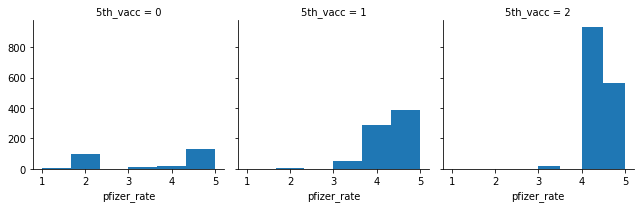

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

a = sns.FacetGrid(data, col='5th_vacc')
a.map(plt.hist, "pfizer_rate", bins=6)

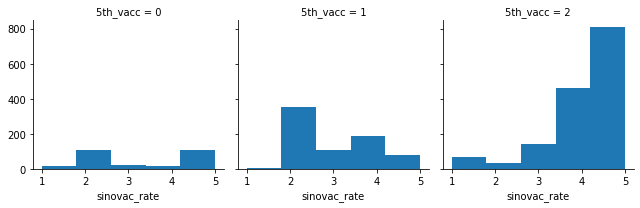

In [ ]:
b = sns.FacetGrid(data, col='5th_vacc')
b.map(plt.hist, "sinovac_rate", bins=5)

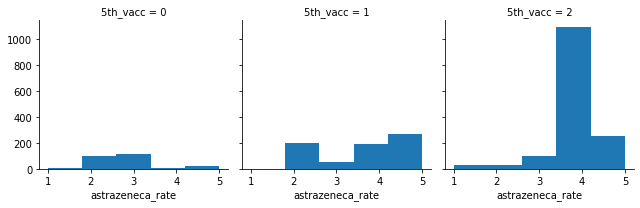

In [ ]:
c = sns.FacetGrid(data, col='5th_vacc')
c.map(plt.hist, "astrazeneca_rate", bins=5)


research prob-2(education)

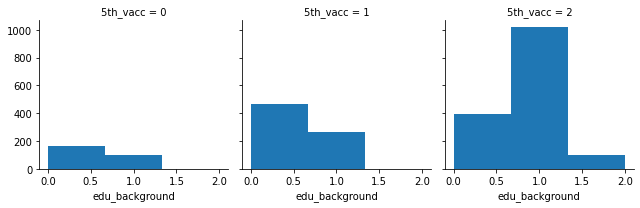

In [ ]:
d = sns.FacetGrid(data, col='5th_vacc')
d.map(plt.hist, "edu_background", bins=3)

research prob-3 motivation

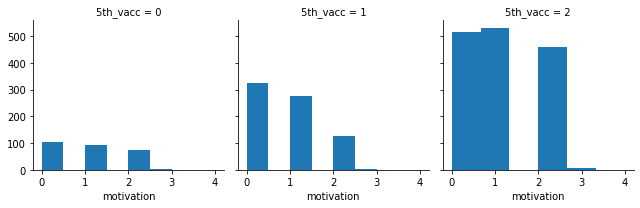

In [ ]:
e = sns.FacetGrid(data, col='5th_vacc')
e.map(plt.hist, "motivation", bins=6)

# NN

In [ ]:
#Assign data from 2nd to 10th column to variable x
x=data.drop(['5th_vacc'], axis=1)

#Assign data from 'Glass type' column to varibale y
y=data['5th_vacc']

In [ ]:
#Train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20)

In [ ]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((2012, 23), (503, 23), (2012,), (503,))

In [ ]:
#Feature scalling (only on train data not test data!)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(x_train)

x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
#Traning and predictions
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPClassifier
mlp=MLPClassifier(hidden_layer_sizes=(10,10,10), max_iter=1000)

mlp.fit(x_train, y_train.values.ravel())

MLPClassifier(hidden_layer_sizes=(10, 10, 10), max_iter=1000)

In [ ]:
#Making predictions
predictions = mlp.predict(x_test)

In [ ]:
#Evaluating algo
from sklearn.metrics import classification_report, confusion_matrix
#print(confusion_matrix(y_test, predictions))
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        65
           1       0.98      0.98      0.98       128
           2       0.99      0.99      0.99       310

    accuracy                           0.99       503
   macro avg       0.99      0.99      0.99       503
weighted avg       0.99      0.99      0.99       503



In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
acc_nn=accuracy_score(y_test,predictions)

acc_nn=accuracy_score(y_test,predictions)
f1_nn=f1_score(y_test,predictions, average="macro")
precision_nn=precision_score(y_test,predictions, average="macro")
recall_nn=recall_score(y_test,predictions, average="macro")

In [ ]:
corr_matrix = data.corr()
print(corr_matrix["5th_vacc"].sort_values(ascending=False))

5th_vacc              1.000000
sinovac_rate          0.386806
edu_background        0.338586
astrazeneca_rate      0.336582
lost_vaccinated       0.327651
cansino_rate          0.266142
vacc2_type            0.237145
pfizer_rate           0.200935
loc                   0.137191
vacc1_type            0.116025
reason_pfizer         0.091019
reason_cansino        0.079239
motivation            0.079235
gender                0.067982
vacc_type_booster1    0.065423
dose                  0.054880
reason_sinovac        0.054658
family_vaccinated     0.046825
reason_astrazeneca   -0.029594
vacc_type_booster2   -0.068404
side_effect2         -0.127245
other_vacc           -0.132157
side_effect1         -0.184162
age                  -0.275694
Name: 5th_vacc, dtype: float64


In [ ]:
#pip install shap

In [ ]:
#import shap as shap

In [ ]:
#explainer = shap.DeepExplainer(mlp, x_train)
#explainer = shap.KernelExplainer(model.predict, x_train)

# calculate shap values. This is what we will plot.
#shap_values = explainer.shap_values(x_test)

# Naiive Bayes

In [ ]:
pip install shutup

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.20, random_state=0)

In [ ]:
from sklearn.naive_bayes import GaussianNB
classifier= GaussianNB()
classifier.fit(X_train,Y_train)

GaussianNB()

In [ ]:
#Predict the test set results
Y_pred=classifier.predict(X_test)
Y_test,Y_pred

(94     2
 56     2
 63     2
 103    2
 21     2
       ..
 5      1
 5      1
 25     1
 88     0
 16     0
 Name: 5th_vacc, Length: 503, dtype: int64,
 array([2, 2, 2, 1, 2, 2, 0, 0, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 2,
        1, 2, 2, 2, 2, 2, 1, 2, 0, 2, 2, 1, 2, 2, 2, 2, 1, 1, 2, 0, 0, 2,
        1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 1, 1, 0, 2, 2,
        2, 2, 1, 2, 2, 1, 2, 2, 1, 1, 2, 1, 1, 2, 2, 1, 0, 2, 2, 2, 2, 1,
        2, 2, 2, 2, 1, 1, 0, 2, 1, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2,
        2, 2, 2, 1, 0, 2, 1, 2, 2, 2, 0, 2, 0, 2, 1, 1, 0, 2, 2, 1, 1, 1,
        1, 0, 1, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 2,
        1, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2, 2, 1, 2, 2, 0, 2, 2, 2, 2, 2,
        1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 1, 2, 0, 1, 2, 2, 2, 2, 1, 2, 2,
        2, 1, 1, 2, 2, 1, 1, 1, 0, 2, 2, 1, 0, 1, 2, 0, 2, 2, 1, 0, 1, 2,
        2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, 1, 0, 2,
        2, 2, 1, 2, 2, 1, 1, 2, 

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
acc_nb=accuracy_score(Y_test,Y_pred)
#print(acc)

#Evaluating algo
#from sklearn.metrics import classification_report, confusion_matrix
#print(confusion_matrix(y_test, predictions))
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.49      0.36      0.41        59
           1       0.68      0.84      0.75       139
           2       0.83      0.79      0.81       305

    accuracy                           0.75       503
   macro avg       0.67      0.66      0.66       503
weighted avg       0.75      0.75      0.75       503



In [ ]:
f1_nb=f1_score(Y_test,Y_pred, average="macro")
precision_nb=precision_score(Y_test,Y_pred, average="macro")
recall_nb=recall_score(Y_test,Y_pred, average="macro")


# Performance comparison

In [ ]:
nn_df = pd.DataFrame(data=[f1_nn,acc_nn, recall_nn,precision_nn],
             columns=['Neural Network (NN) Score'],
             index=["F1","Accuracy", "Recall", "Precision"])

nb_df = pd.DataFrame(data=[f1_nb,acc_nb, recall_nb,precision_nb],
             columns=['Naive Bayed (NB) Score'],
             index=["F1","Accuracy", "Recall", "Precision"])

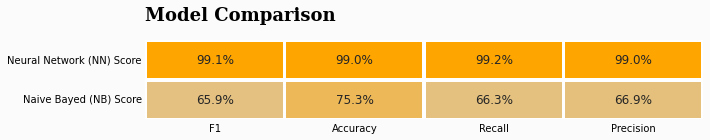

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

df_models = round(pd.concat([nn_df,nb_df], axis=1),3)

colors = ["lightgray","lightgray","orange"]
colormap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)

background_color = "#fbfbfb"

fig = plt.figure(figsize=(10,8)) # create figure
gs = fig.add_gridspec(4, 2)
gs.update(wspace=0.1, hspace=0.5)
ax0 = fig.add_subplot(gs[0, :])

sns.heatmap(df_models.T, cmap=colormap,annot=True,fmt=".1%",vmin=0,vmax=0.95, linewidths=2.5,cbar=False,ax=ax0,annot_kws={"fontsize":12})
fig.patch.set_facecolor(background_color) # figure background color
ax0.set_facecolor(background_color)

ax0.text(0,-0.5,'Model Comparison',fontsize=18,fontweight='bold',fontfamily='serif')
ax0.tick_params(axis=u'both', which=u'both',length=0)